#  Iris Flower Species Classification
## End-to-End Machine Learning Project using Scikit-learn

**Author:** Aleesha Nadeem


**Tools Used**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

---

#  Introduction

Machine Learning enables computers to learn patterns from historical data and make predictions without being explicitly programmed.

In this project, we build a Machine Learning classification model to identify Iris flower species based on their physical measurements.

The Iris dataset is one of the most popular beginner-friendly datasets in Machine Learning and is widely used to understand the complete workflow of a classification problem.

This notebook covers the entire process, from loading the dataset to evaluating the final model.



#  Objectives

The main objectives of this project are:

- Understand the Iris dataset.
- Perform data exploration and visualization.
- Prepare the dataset for Machine Learning.
- Train multiple classification models.
- Evaluate model performance.
- Compare different algorithms.
- Predict Iris flower species accurately.




#  Dataset Overview

The Iris dataset contains measurements of Iris flowers.

Each record represents one flower.

The dataset contains four numerical features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

**Target Variable:**

- Iris Setosa
- Iris Versicolor
- Iris Virginica

The goal is to correctly classify each flower into its respective species.

#  Import  Libraries


In [1]:

import warnings 
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

#  Load the Dataset

Before building any Machine Learning model, the first step is to load and inspect the dataset.

In this section, we will:

- Load the dataset using Pandas.
- Display the first few rows.
- Understand the structure of the data.
- Verify that the dataset has been loaded correctly.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/saurabh00007/iriscsv/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Basic Data Exploration

Understanding the dataset is one of the most important steps in any Data Science project.

Here we will examine:

- Number of rows and columns
- Column names
- Data types
- Missing values
- Statistical summary

In [3]:
# Shape of the dataset
print("Shape of Dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data information
print("\nDataset Information:\n")
df.info()

Shape of Dataset: (150, 6)

Columns:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,150.0,75.500000,43.445368,1.0,38.25,75.50,112.75,150.0
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.10,5.80,6.40,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.80,3.00,3.30,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.60,4.35,5.10,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.30,1.30,1.80,2.5


In [5]:
# Missing Values
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [6]:
# Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


#  Exploratory Data Analysis (EDA)

EDA helps us understand patterns, relationships, and distributions in the dataset before building Machine Learning models.

We will visualize the data using different charts.

In [7]:
df.sample(5, random_state=42)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
73,74,6.1,2.8,4.7,1.2,Iris-versicolor
18,19,5.7,3.8,1.7,0.3,Iris-setosa
118,119,7.7,2.6,6.9,2.3,Iris-virginica
78,79,6.0,2.9,4.5,1.5,Iris-versicolor
76,77,6.8,2.8,4.8,1.4,Iris-versicolor


## Distribution of Flower Species

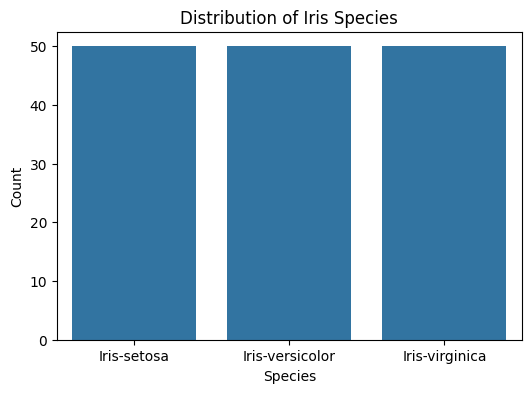

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Species"
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

##  Pair Plot

A pair plot helps us understand the relationship between every pair of numerical features.

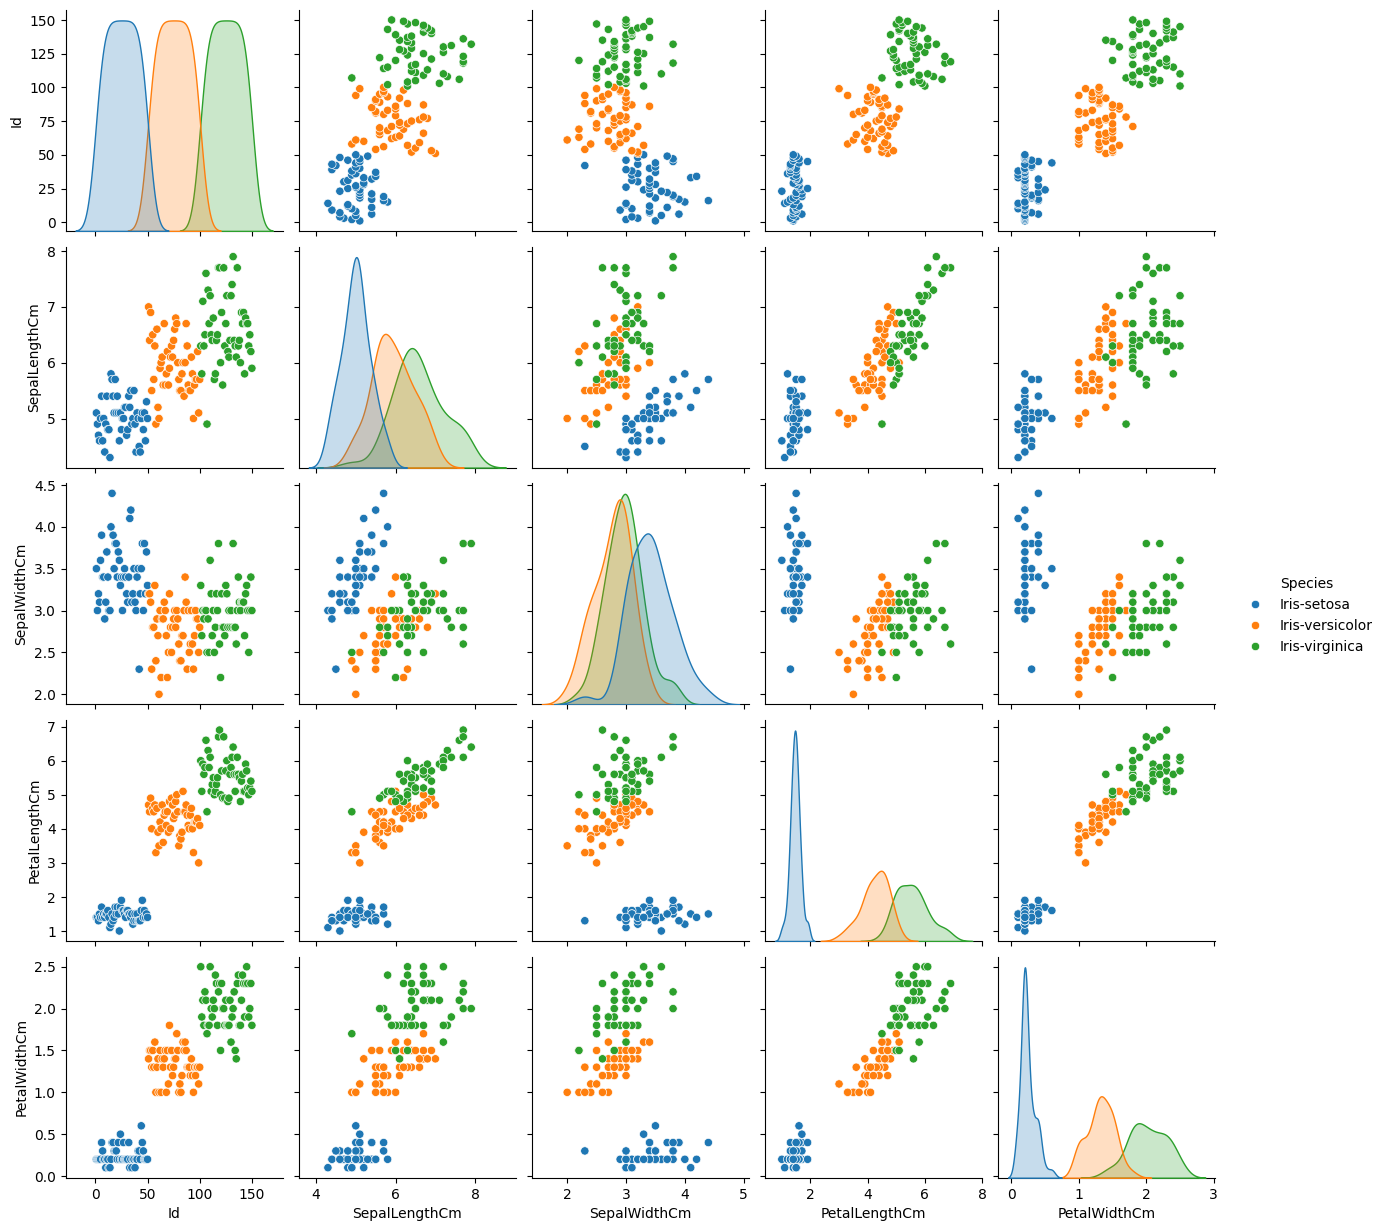

In [9]:
sns.pairplot(
    df,
    hue="Species"
)

plt.show()

## 🔥 Correlation Heatmap

The heatmap shows the correlation between numerical features.

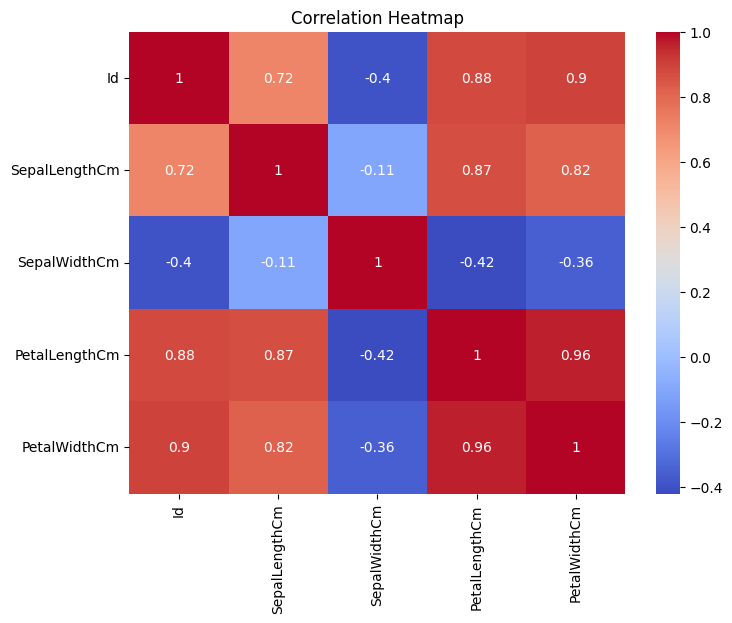

In [10]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Boxplots

Boxplots help identify the spread of data and detect potential outliers.

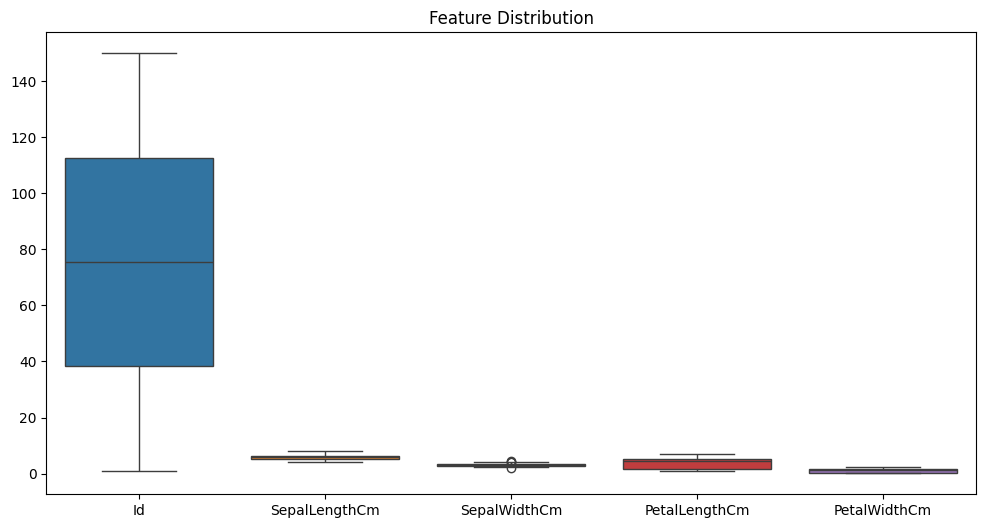

In [11]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.title("Feature Distribution")

plt.show()

## 📈 Feature Distribution

Histograms help us understand the distribution of numerical features.

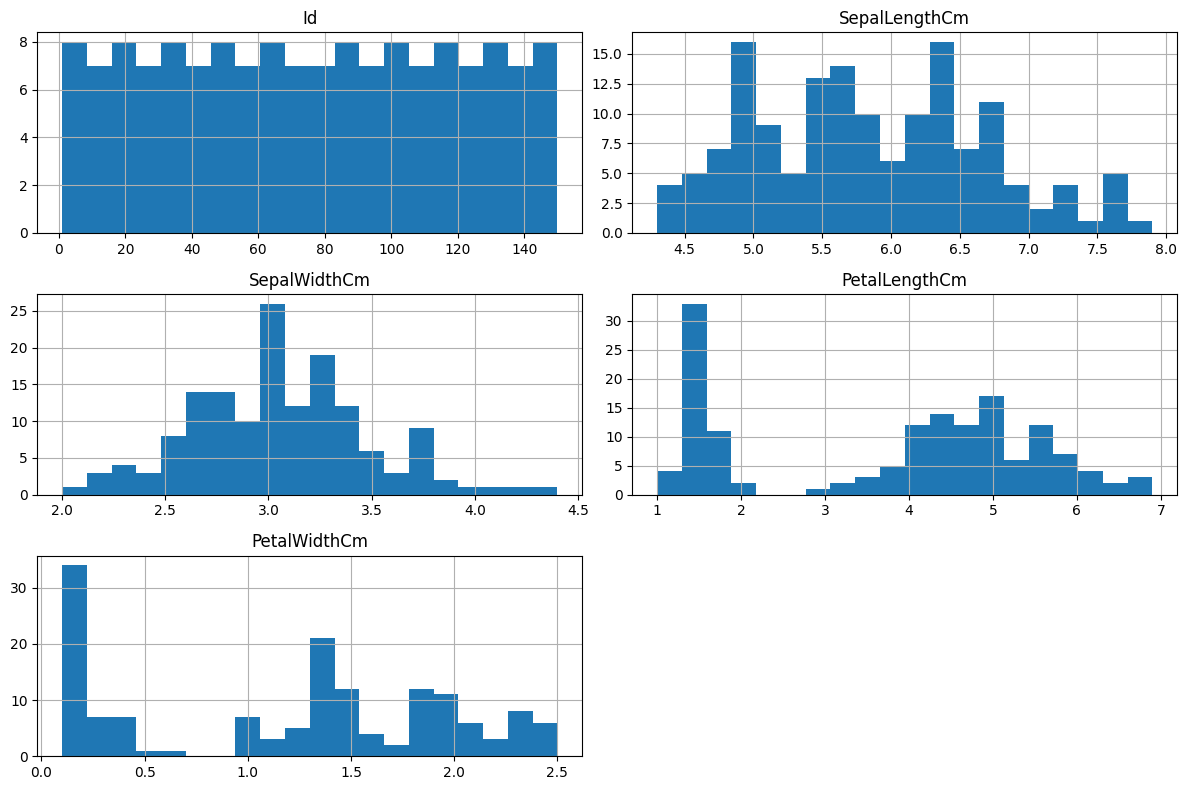

In [12]:
df.hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()

plt.show()

##  Violin Plot

A violin plot combines the information of a boxplot and a density plot.

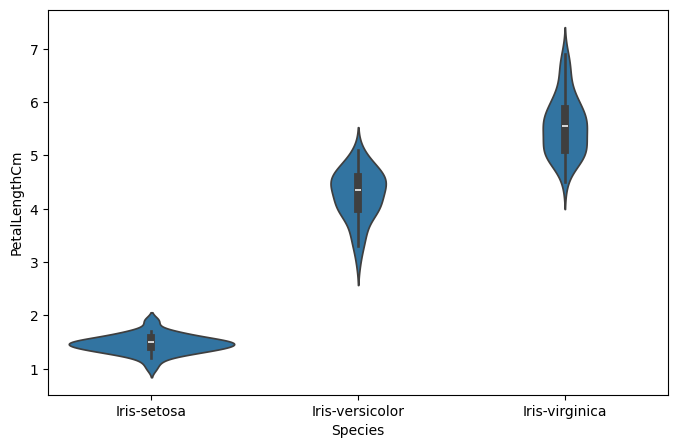

In [13]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Species",
    y="PetalLengthCm"
)

plt.show()

##  Relationship Between Petal Length and Petal Width

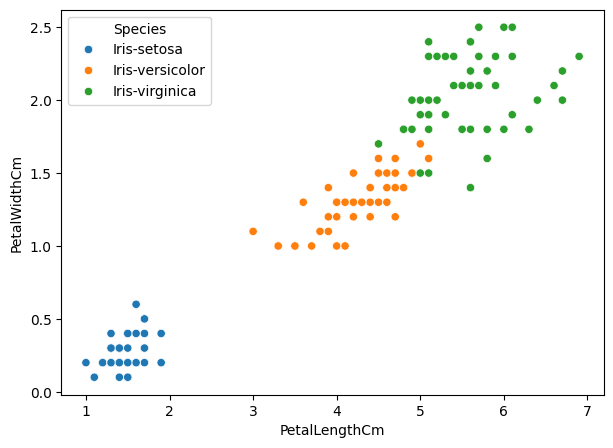

In [14]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species"
)

plt.show()

#  Feature Selection

Feature Selection is the process of selecting the input variables that will be used to train the Machine Learning model.

For this project:

**Features (X):**

- SepalLengthCm
- SepalWidthCm
- PetalLengthCm
- PetalWidthCm

**Target (y):**

- Species

The model will learn the relationship between these flower measurements and their corresponding species.

In [15]:
X = df.drop(columns=["Id", "Species"])

y = df["Species"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (150, 4)
Target Shape : (150,)


#  Train-Test Split

Machine Learning models should not be evaluated on the same data they were trained on.

Therefore, we split the dataset into two parts:

- Training Data (80%)
- Testing Data (20%)

The model learns from the training data and is evaluated using the testing data to measure its performance on unseen data.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (120, 4)
Testing Features : (30, 4)
Training Labels : (120,)
Testing Labels : (30,)


#  Decision Tree Classifier

A Decision Tree is a supervised Machine Learning algorithm used for classification and regression tasks.

It works by repeatedly splitting the dataset into smaller subsets based on feature values. Each decision is represented as a node, and the final prediction is made at the leaf node.

### Why Decision Tree?

- Easy to understand and interpret.
- Suitable for classification problems.
- No feature scaling required.
- Performs well on small datasets like Iris.
- Provides visual representation of decision-making.

In [17]:
# Create Decision Tree Model

model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

#  Train the Model

Training is the learning phase of Machine Learning.

During training, the model learns the relationship between flower measurements (features) and their corresponding species (target labels).

After training, the model becomes capable of predicting the species of unseen flowers.

In [18]:
model.fit(X_train, y_train)

print(" Model Trained Successfully!")

 Model Trained Successfully!


In [19]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

#  Make Predictions

Now that the model has learned from the training data, it can predict the species of unseen flowers.

Predictions are made using the testing dataset.

In [20]:
y_pred = model.predict(X_test)

In [21]:
comparison = pd.DataFrame({
    "Actual Species": y_test.values,
    "Predicted Species": y_pred
})

comparison.head(10)

,Actual Species,Predicted Species
0,Iris-setosa,Iris-setosa
1,Iris-virginica,Iris-virginica
2,Iris-versicolor,Iris-versicolor
3,Iris-versicolor,Iris-versicolor
4,Iris-setosa,Iris-setosa
5,Iris-versicolor,Iris-versicolor
6,Iris-setosa,Iris-setosa
7,Iris-setosa,Iris-setosa
8,Iris-virginica,Iris-virginica
9,Iris-versicolor,Iris-versicolor


#  Model Evaluation

After training a Machine Learning model, it is important to evaluate its performance.

Model evaluation helps us understand how well the model performs on unseen data.

In this section, we will evaluate the model using:

- Accuracy Score
- Confusion Matrix
- Classification Report

In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 93.33%


#  Confusion Matrix

A Confusion Matrix provides a detailed summary of model predictions.

It shows:

- Correct Predictions
- Incorrect Predictions

A perfect model will have all values concentrated along the diagonal.

In [23]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  1,  9]])

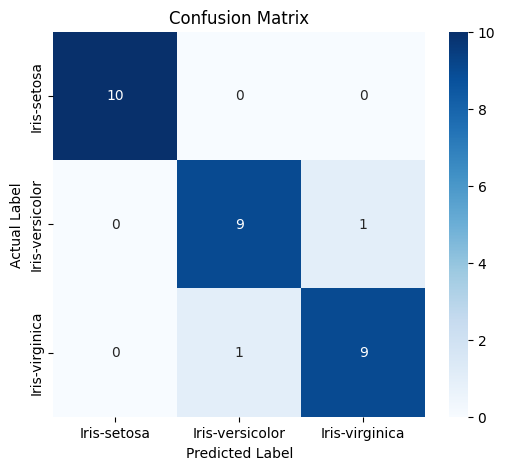

In [24]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

**The diagonal values represent correct predictions, while off-diagonal values indicate misclassifications. Since most values lie on the diagonal, the model performs well.**

#  Classification Report

The Classification Report provides detailed evaluation metrics for each class.

It includes:

- Precision
- Recall
- F1-Score
- Support

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



#  Feature Importance

Feature Importance tells us which flower measurements were most influential in making predictions.

This helps us understand how the Decision Tree makes decisions.

In [27]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,PetalLengthCm,0.558568
3,PetalWidthCm,0.406015
1,SepalWidthCm,0.029167
0,SepalLengthCm,0.006250


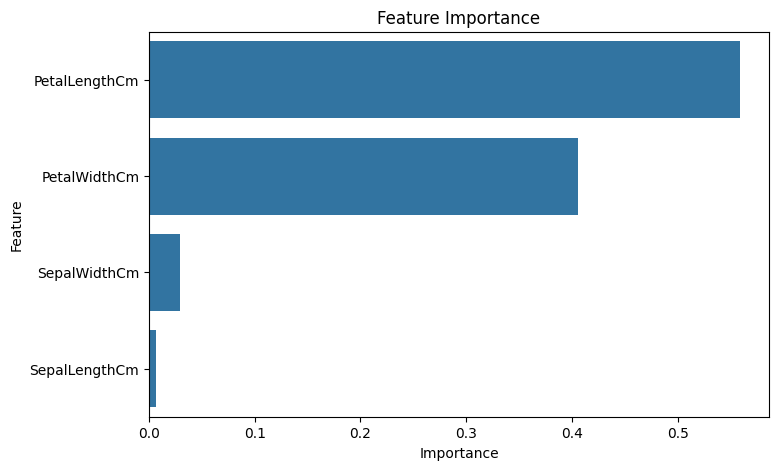

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

# ✅ Conclusion

In this project, we successfully built a Machine Learning model to classify Iris flower species using the Decision Tree Classifier.

The workflow included:

- Data Loading
- Data Exploration
- Exploratory Data Analysis (EDA)
- Feature Selection
- Train-Test Split
- Model Training
- Model Evaluation

The Decision Tree Classifier achieved strong performance on the Iris dataset and demonstrated its ability to accurately classify flower species based on their physical measurements.

This project provides a solid foundation for understanding supervised Machine Learning classification problems.